In [1]:
# Import necessary libraries
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import json

# Login to wandb (if not already logged in)
wandb.login()

# Define the project and entity
project_name = "Negatives_review"
entity_name = "ntourne"

# Initialize the wandb API
api = wandb.Api()

# Fetch all runs from the project
runs = api.runs(f"{entity_name}/{project_name}")

/data/home/natant/anaconda3/envs/Negs2/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/data/home/natant/anaconda3/envs/Negs2/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happ

# Loading Data and Quality control

In [3]:
# Initialize a list to store results
results = []

# Iterate through runs and extract metrics
for run in runs:
    # Get the summary metrics, config, and name of the run
    summary = run.summary._json_dict
    if isinstance(summary, str):
        summary = json.loads(summary)
    config = run.config
    if isinstance(config, str):
        config = json.loads(config)
    name = run.name
    
    # Combine the data into a single dictionary
    run_data = {
        "run_name": name,
        "TF": config.get("TF")["value"],
        "celltype": config.get("celltype")["value"],
        "neg_mode": [config.get("neg_mode")["value"] if "neg_mode" in config else "HQ training"][0],
        "cross_val_set": config.get("cross_val_set")["value"],
        "group_name": config.get("group_name")["value"],
        "AUROC": summary.get("test_AUROC"),
        "AUROC_HQ": summary.get("test_AUROC_HQ"),
        "val_loss": summary.get("val_loss"),
        "Accuracy": summary.get("test_Accuracy"),
        "Accuracy_HQ": summary.get("test_Accuracy_HQ"),
        "Average_Precision": summary.get("test_Average_precision"),
        "Average_Precision_HQ": summary.get("test_Average_precision_HQ"),
        "Matthews_Correlation": summary.get("test_Matthews_corr_coef"),
        "Matthews_Correlation_HQ": summary.get("test_Matthews_corr_coef_HQ"),
        "Precision": summary.get("test_Precision"),
        "Precision_HQ": summary.get("test_Precision_HQ"),
        "Specificity": summary.get("test_Specificity"),
        "Specificity_HQ": summary.get("test_Specificity_HQ")
    }
    results.append(run_data)

# Convert the results into a DataFrame
results_df = pd.DataFrame(results)
#results_df = results_df[results_df["celltype"] == "GM12878"]

KeyboardInterrupt: 

In [ ]:
pd.DataFrame(results)

,run_name,TF,celltype,neg_mode,cross_val_set,group_name,AUROC,AUROC_HQ,val_loss,Accuracy,Accuracy_HQ,Average_Precision,Average_Precision_HQ,Matthews_Correlation,Matthews_Correlation_HQ,Precision,Precision_HQ,Specificity,Specificity_HQ
0,GM12878_CTCF_CV5_20251030_14:40,CTCF,GM12878,dinucl_sampled,5,Review_rerun_1,0.985959,0.970368,0.241992,0.947212,0.833103,0.991579,0.848164,0.891851,0.600585,0.997684,0.910051,0.998070,0.993729
1,GM12878_CTCF_CV0_20251030_14:40,CTCF,GM12878,dinucl_sampled,0,Review_rerun_1,0.980963,0.964398,0.228903,0.938503,0.833124,0.989299,0.825617,0.866462,0.544887,0.998703,0.967935,0.999541,0.999257
2,GM12878_CTCF_CV4_20251030_14:40,CTCF,GM12878,dinucl_sampled,4,Review_rerun_1,0.981297,0.964039,0.217291,0.934676,0.795560,0.989341,0.830676,0.865102,0.583756,1.000000,0.991781,1.000000,0.999969
3,GM12878_CTCF_CV2_20251030_14:40,CTCF,GM12878,dinucl_sampled,2,Review_rerun_1,0.978838,0.964429,0.334130,0.931050,0.795142,0.988499,0.820560,0.863820,0.587741,0.985914,0.640458,0.977757,0.944465
4,GM12878_CTCF_CV1_20251030_14:40,CTCF,GM12878,dinucl_sampled,1,Review_rerun_1,0.978207,0.955146,0.394063,0.933548,0.843779,0.986997,0.749525,0.856492,0.568876,0.981579,0.581510,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3511,CROSS-CELL-PERF_GM12878-A549_ATF3_HQ-training_...,ATF3,A549,HQ training,1,Review_cross_cell_perf,0.410633,NaN,NaN,0.979650,NaN,0.016804,NaN,0.022377,NaN,0.018528,NaN,1.000000,NaN
3512,CROSS-CELL-PERF_GM12878-A549_ATF3_HQ-training_...,ATF3,A549,HQ training,4,Review_cross_cell_perf,0.462397,NaN,NaN,0.979650,NaN,0.021906,NaN,0.022377,NaN,0.500000,NaN,1.000000,NaN
3513,CROSS-CELL-PERF_GM12878-A549_ATF3_HQ-training_...,ATF3,A549,HQ training,0,Review_cross_cell_perf,0.444370,NaN,NaN,0.977029,NaN,0.021082,NaN,0.017389,NaN,0.025210,NaN,1.000000,NaN
3514,CROSS-CELL-PERF_GM12878-A549_ATF3_HQ-training_...,ATF3,A549,HQ training,5,Review_cross_cell_perf,0.424218,NaN,NaN,0.979083,NaN,0.018229,NaN,0.023978,NaN,0.020920,NaN,1.000000,NaN


In [3]:
import pickle

# Path to the pickle file
pickle_path = "/data/home/natant/Negatives/Results/results_review_run_1.pkl"

# Load results_df from pickle
with open(pickle_path, "rb") as f:
    results_df = pickle.load(f)

results_df

,run_name,TF,celltype,neg_mode,cross_val_set,group_name,AUROC,AUROC_HQ,val_loss,Accuracy,Accuracy_HQ,Average_Precision,Average_Precision_HQ,Matthews_Correlation,Matthews_Correlation_HQ,Precision,Precision_HQ,Specificity,Specificity_HQ
0,GM12878_CTCF_CV5_20251030_14:40,CTCF,GM12878,dinucl_sampled,5,Review_rerun_1,0.985959,0.970368,0.241992,0.947212,0.833103,0.991579,0.848164,0.891851,0.600585,0.997684,0.910051,0.998070,0.993729
1,GM12878_CTCF_CV0_20251030_14:40,CTCF,GM12878,dinucl_sampled,0,Review_rerun_1,0.980963,0.964398,0.228903,0.938503,0.833124,0.989299,0.825617,0.866462,0.544887,0.998703,0.967935,0.999541,0.999257
2,GM12878_CTCF_CV4_20251030_14:40,CTCF,GM12878,dinucl_sampled,4,Review_rerun_1,0.981297,0.964039,0.217291,0.934676,0.795560,0.989341,0.830676,0.865102,0.583756,1.000000,0.991781,1.000000,0.999969
3,GM12878_CTCF_CV2_20251030_14:40,CTCF,GM12878,dinucl_sampled,2,Review_rerun_1,0.978838,0.964429,0.334130,0.931050,0.795142,0.988499,0.820560,0.863820,0.587741,0.985914,0.640458,0.977757,0.944465
4,GM12878_CTCF_CV1_20251030_14:40,CTCF,GM12878,dinucl_sampled,1,Review_rerun_1,0.978207,0.955146,0.394063,0.933548,0.843779,0.986997,0.749525,0.856492,0.568876,0.981579,0.581510,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423,GM12878_ZNF274_CV1_20251103_23:41,ZNF274,GM12878,celltype,1,Review_rerun_1_CT,0.911765,0.902446,0.743223,0.649485,0.999689,0.904884,0.198895,0.774956,0.110604,1.000000,0.183333,1.000000,0.999551
1424,GM12878_ZNF274_CV2_20251103_23:45,ZNF274,GM12878,celltype,2,Review_rerun_1_CT,0.923186,0.928172,0.282235,0.738095,0.646896,0.919696,0.435035,0.789662,0.114807,1.000000,0.031898,1.000000,0.992021
1425,GM12878_ZNF274_CV3_20251103_23:45,ZNF274,GM12878,celltype,3,Review_rerun_1_CT,0.862258,0.928388,0.535662,0.691542,0.964816,0.937129,0.083884,0.547221,0.087687,1.000000,0.103053,1.000000,0.997767
1426,GM12878_ZNF274_CV4_20251103_23:47,ZNF274,GM12878,celltype,4,Review_rerun_1_CT,0.850140,0.892421,1.289174,0.649485,0.999680,0.828554,0.063431,0.630288,0.068964,1.000000,0.029070,1.000000,0.995413


In [4]:
#results_df = pd.DataFrame(results)
results_df = results_df[results_df["celltype"] == "GM12878"]
results_df = results_df[results_df['group_name'].isin(["Review_rerun_1", "Review_rerun_1_HQ", "Review_rerun_1_CT"])] # select the right groups
# HQ_results = pd.DataFrame(results)
# HQ_results = HQ_results[HQ_results['group_name'] == "full_run_3_HQ"]
# HQ_results["neg_mode"] = "HQ training"
# HQ_results = HQ_results.rename(columns={"AUROC": "AUROC_HQ", "AUROC_HQ": "AUROC"})
# HQ_results = HQ_results[HQ_results['celltype'].isin(['A549', 'GM12878', 'K562', 'HepG2'])] # only the right celltypes
# Merge results_df with HQ_results, aligning columns as needed
# results_df = pd.concat([results_df, HQ_results], ignore_index=True)

In [5]:
# Exclude rows where neg_mode is 'HQ training' before checking for NaNs in AUROC
mask = results_df["neg_mode"] != "HQ training"
num_nans = results_df.loc[mask, "AUROC"].isna().sum()
print(f"Number of NaNs in AUROC (excluding HQ training): {num_nans}")
results_df.loc[mask & results_df["AUROC"].isna()]

Number of NaNs in AUROC (excluding HQ training): 0


,run_name,TF,celltype,neg_mode,cross_val_set,group_name,AUROC,AUROC_HQ,val_loss,Accuracy,Accuracy_HQ,Average_Precision,Average_Precision_HQ,Matthews_Correlation,Matthews_Correlation_HQ,Precision,Precision_HQ,Specificity,Specificity_HQ


There should be no NaNs!!

In [6]:
# Filter out entries where AUROC_HQ == 0 -> probably an issue with the cross val split 
filtered_out_count = results_df[(results_df['AUROC_HQ'] == 0) | (results_df['AUROC_HQ'].isna())].shape[0]

# Filter the DataFrame to exclude these entries
#results_df = results_df[~((results_df['AUROC_HQ'] == 0) | (results_df['AUROC_HQ'].isna()))]

# Print the count of filtered-out entries
print(f"Number of entries where AUROC_HQ == 0 or NaN: {filtered_out_count}")

Number of entries where AUROC_HQ == 0 or NaN: 216


Also no 0's!!

In [7]:
results_df["celltype_TF"] = results_df["celltype"]+"_"+results_df["TF"]
output = results_df["celltype_TF"].value_counts()
output.to_dict()

{'GM12878_CTCF': 36,
 'GM12878_YY1_(SC-281)': 36,
 'GM12878_TBP': 36,
 'GM12878_Egr-1': 36,
 'GM12878_Mxi1_(AF4185)': 36,
 'GM12878_SRF': 36,
 'GM12878_MAZ_(ab85725)': 36,
 'GM12878_ELK1_(1277-1)': 36,
 'GM12878_SIX5': 36,
 'GM12878_USF-1': 36,
 'GM12878_SP1': 36,
 'GM12878_RFX5_(200-401-194)': 36,
 'GM12878_ELF1_(SC-631)': 36,
 'GM12878_ATF2_(SC-81188)': 36,
 'GM12878_NF-YB': 36,
 'GM12878_USF2': 36,
 'GM12878_Znf143_(16618-1-AP)': 36,
 'GM12878_ZEB1_(SC-25388)': 36,
 'GM12878_Pbx3': 36,
 'GM12878_MEF2A': 36,
 'GM12878_TCF12': 36,
 'GM12878_Max': 36,
 'GM12878_STAT5A_(SC-74442)': 36,
 'GM12878_NFIC_(SC-81335)': 36,
 'GM12878_Nrf1': 36,
 'GM12878_CEBPB_(SC-150)': 36,
 'GM12878_FOXM1_(SC-502)': 36,
 'GM12878_RXRA': 36,
 'GM12878_ZBTB33': 36,
 'GM12878_ETS1': 36,
 'GM12878_ATF3': 36,
 'GM12878_NF-YA': 36,
 'GM12878_IKZF1_(IkN)_(UCLA)': 36,
 'GM12878_JunD': 36,
 'GM12878_ZZZ3': 36,
 'GM12878_ZNF274': 36}

There really shouldn't be any with less runs, so check if something is wrong!!

In [9]:
# Filter out TFs with less than 36 samples
#results_df = results_df.groupby('celltype_TF').filter(lambda x: len(x) >= 36) #! ONLY TAKE THE 4 BIG CELL TYPES

In [10]:
results_df["celltype"].value_counts() 

celltype
GM12878    1296
Name: count, dtype: int64

In [8]:
results_df["TF-neg_mode"] = results_df["TF"]+"_"+results_df["neg_mode"]
results_df["TF-neg_mode-celltype"] = results_df["TF"]+"_"+results_df["neg_mode"]+"_"+results_df["celltype"]

In [9]:
tf_per_celltype = results_df.groupby("celltype")["TF"].nunique()
print(tf_per_celltype)

celltype
GM12878    36
Name: TF, dtype: int64


In [12]:
results_df = results_df[~results_df["TF"].isin(["ZNF274", "IRF3", "ZZZ3"])]
results_df["TF"].value_counts()

TF
CTCF                   36
YY1_(SC-281)           36
TBP                    36
Egr-1                  36
Mxi1_(AF4185)          36
SRF                    36
MAZ_(ab85725)          36
ELK1_(1277-1)          36
SIX5                   36
USF-1                  36
SP1                    36
RFX5_(200-401-194)     36
ELF1_(SC-631)          36
ATF2_(SC-81188)        36
NF-YB                  36
USF2                   36
Znf143_(16618-1-AP)    36
ZEB1_(SC-25388)        36
Pbx3                   36
MEF2A                  36
TCF12                  36
Max                    36
STAT5A_(SC-74442)      36
NFIC_(SC-81335)        36
Nrf1                   36
CEBPB_(SC-150)         36
FOXM1_(SC-502)         36
RXRA                   36
ZBTB33                 36
ETS1                   36
ATF3                   36
NF-YA                  36
IKZF1_(IkN)_(UCLA)     36
JunD                   36
Name: count, dtype: int64

In [14]:
results_df["neg_mode"].value_counts()

neg_mode
dinucl_sampled     204
dinucl_shuffled    204
shuffled           204
neighbors          204
celltype           204
HQ training        204
Name: count, dtype: int64

In [15]:
results_df["TF-neg_mode-celltype"].value_counts()[results_df["TF-neg_mode-celltype"].value_counts() <6]

Series([], Name: count, dtype: int64)

In [16]:
np.sum([6- i for i in results_df["TF-neg_mode-celltype"].value_counts()[results_df["TF-neg_mode-celltype"].value_counts() <6].values])

np.float64(0.0)

In [17]:
# Get all possible combinations that should exist
all_combinations = []
for tf in results_df['TF'].unique():
    for celltype in results_df['celltype'].unique():
        for neg_mode in results_df['neg_mode'].unique():
            # Skip combinations that don't exist at all (not all TFs exist in all celltypes)
            if results_df[(results_df['TF'] == tf) & 
                          (results_df['celltype'] == celltype) & 
                          (results_df['neg_mode'] == neg_mode)].shape[0] > 0:
                for cv_fold in range(6):  # 6 folds: 0-5
                    all_combinations.append({
                        'TF': tf,
                        'celltype': celltype,
                        'neg_mode': neg_mode,
                        'cross_val_set': cv_fold
                    })

# Convert to DataFrame
expected_df = pd.DataFrame(all_combinations)

# Merge with actual runs to find missing ones
actual_runs = results_df[['TF', 'celltype', 'neg_mode', 'cross_val_set']].drop_duplicates()
missing_runs = pd.merge(
    expected_df, 
    actual_runs, 
    on=['TF', 'celltype', 'neg_mode', 'cross_val_set'], 
    how='left', 
    indicator=True
)

# Filter to only missing runs
missing_runs = missing_runs[missing_runs['_merge'] == 'left_only'].drop(columns=['_merge'])

# Add group_name based on neg_mode
missing_runs['group_name'] = missing_runs['neg_mode'].apply(
    lambda x: 'full_run_3_HQ' if x == 'HQ training' else 'full_run_3'
)

# Sort for better readability
missing_runs = missing_runs.sort_values(['celltype', 'TF', 'neg_mode', 'cross_val_set']).reset_index(drop=True)

In [17]:
missing_runs

,TF,celltype,neg_mode,cross_val_set,group_name


In [18]:
# # Write the missing_runs DataFrame to a CSV file
# missing_runs.to_csv("/data/home/natant/Negatives/Runs/full_run_3_missing/missing_runs.csv", index=False)
# print(f"Exported {len(missing_runs)} missing runs to missing_runs.csv")

In [18]:
results_df["AUROC_delta"] = results_df["AUROC"] - results_df["AUROC_HQ"]

In [19]:
import pickle

with open("/data/home/natant/Negatives/testing_ground/20250613_NUMBER_OF_POSITIVES_PER_GROUP.pkl", "rb") as f:
    number_of_positives = pickle.load(f)
# Convert the nested dictionary 'number_of_positives' into a pandas DataFrame
number_of_positives_df = (
    pd.DataFrame([
        {"celltype": ct, "TF": tf, "positives 1": vals[0], "positives 2": vals[1], "positives 3": vals[2]}
        for ct, tf_dict in number_of_positives.items()
        for tf, vals in tf_dict.items()
    ])
)
number_of_positives_df

,celltype,TF,positives 1,positives 2,positives 3
0,MCF-7,CTCF,7124,5733,8144
1,MCF-7,TCF7L2,2909,2949,4439
2,MCF-7,ZNF217,2911,2775,4259
3,MCF-7,GATA3_(SC-268),1853,1606,2624
4,GM12878,CTCF,12222,12053,15832
...,...,...,...,...,...
127,A549,USF-1,2170,2457,3821
128,A549,ETS1,1535,1503,2503
129,A549,SIX5,1488,1318,2109
130,A549,ZBTB33,1896,2039,3222


In [20]:
from itertools import permutations
all_orderings = list(permutations(["part1", "part2", "part3"]))
ordering_dict = {i: ordering[0] for i, ordering in enumerate(all_orderings)}
# Map cross_val_set to the corresponding positives column using two dictionaries
crossval_to_part = ordering_dict  # e.g., {0: 'part1', 1: 'part1', 2: 'part2', ...}
part_to_col = {"part1": "positives 1", "part2": "positives 2", "part3": "positives 3"}

def lookup_num_training_positives(row):
    part = crossval_to_part[int(row['cross_val_set'])]
    part_col = part_to_col.get(part)
    match = number_of_positives_df[
        (number_of_positives_df['celltype'] == row['celltype']) &
        (number_of_positives_df['TF'] == row['TF'])
    ]
    if not match.empty and part_col is not None:
        return match.iloc[0][part_col]
    else:
        return np.nan

results_df["num_training_positives"] = results_df.apply(lookup_num_training_positives, axis=1)


In [22]:
results_df.columns

Index(['run_name', 'TF', 'celltype', 'neg_mode', 'cross_val_set', 'group_name',
       'AUROC', 'AUROC_HQ', 'val_loss', 'Accuracy', 'Accuracy_HQ',
       'Average_Precision', 'Average_Precision_HQ', 'Matthews_Correlation',
       'Matthews_Correlation_HQ', 'Precision', 'Precision_HQ', 'Specificity',
       'Specificity_HQ', 'celltype_TF', 'TF-neg_mode', 'TF-neg_mode-celltype',
       'AUROC_delta', 'num_training_positives'],
      dtype='object')

## Dataframe 1: results_df
Contains all the results, without averaging the different cross_val folds

In [21]:
# Group by TF, celltype, and neg_mode, then average AUROC and AUROC_HQ
grouped_avg = results_df.groupby(['TF', 'celltype', 'neg_mode'], as_index=False)[['AUROC', 'AUROC_HQ', 'num_training_positives', 'Accuracy', 'Accuracy_HQ','Average_Precision', 'Average_Precision_HQ', 'Matthews_Correlation', 'Matthews_Correlation_HQ', 'Precision', 'Precision_HQ', 'Specificity','Specificity_HQ']].mean()
grouped_avg["TF-neg_mode"] = grouped_avg["TF"] + "-" + grouped_avg["neg_mode"]
grouped_avg

metrics = [
    ('AUROC', 'AUROC_value', 'auroc_metric'),
    ('Average_Precision', 'Average_Precision_value', 'Average_Precision_metric'),
    ('Accuracy', 'Accuracy_value', 'Accuracy_metric'),
    ('Matthews_Correlation', 'Matthews_Correlation_value', 'Matthews_Correlation_metric'),
    ('Precision', 'Precision_value', 'Precision_metric'),
    ('Specificity', 'Specificity_value', 'Specificity_metric')
]
for metric, _, _ in metrics:
    grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training",str(metric+"_HQ")] = grouped_avg[grouped_avg["neg_mode"] == "HQ training"][metric]
    grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training",metric] = np.nan

# grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training","AUROC_HQ"] = grouped_avg[grouped_avg["neg_mode"] == "HQ training"]["AUROC"]
# grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training","AUROC"] = np.nan

## Dataframe 2: grouped_avg
Contains all the results, with averaged AUROC and AUROC_HQ over the different cross_val_folds

In [26]:
import pickle

motif_results_path = "/data/home/natant/Negatives/Runs/Review_rerun/MOTIFS/GM12878_MOTIFS.pkl"

with open(motif_results_path, "rb") as f:
    gm12878_motif_results = pickle.load(f)

gm12878_motif_results

,AUROC_1,AUROC_2,AUROC_3,PRAUC_1,PRAUC_2,PRAUC_3,Accuracy_1,Accuracy_threshold_1,Accuracy_2,Accuracy_threshold_2,...,Recall_2,Recall_threshold_2,Recall_3,Recall_threshold_3,Specificity_1,Specificity_threshold_1,Specificity_2,Specificity_threshold_2,Specificity_3,Specificity_threshold_3
CTCF,0.888889,1.000000,0.950311,0.488889,1.000000,0.923810,0.433333,0.93,0.500000,0.83,...,1.0,0.01,1.0,0.01,0.370370,0.93,0.423077,0.83,0.217391,0.88
YY1_(SC-281),0.948276,0.696429,0.379310,0.333333,0.297619,0.043478,0.033333,0.01,0.066667,0.01,...,1.0,0.01,1.0,0.01,0.000000,0.01,0.000000,0.01,0.000000,0.01
Egr-1,0.964286,0.862069,NaN,0.583333,0.200000,NaN,0.500000,0.49,0.300000,0.41,...,1.0,0.01,NaN,NaN,0.464286,0.49,0.275862,0.41,NaN,NaN
Mxi1_(AF4185),1.000000,0.392857,NaN,1.000000,0.079193,NaN,0.366667,0.99,0.266667,0.76,...,1.0,0.01,NaN,NaN,0.344828,0.99,0.214286,0.76,NaN,NaN
SRF,0.740741,0.724138,NaN,0.494444,0.111111,NaN,0.566667,0.94,0.733333,0.63,...,1.0,0.01,NaN,NaN,0.555556,0.94,0.724138,0.63,NaN,NaN
MAZ_(ab85725),NaN,0.785714,NaN,NaN,0.571429,NaN,NaN,NaN,0.566667,0.01,...,0.5,0.01,NaN,NaN,NaN,NaN,0.571429,0.01,NaN,NaN
ELK1_(1277-1),1.000000,0.931034,NaN,1.000000,0.333333,NaN,0.033333,0.01,0.100000,0.01,...,1.0,0.01,NaN,NaN,0.000000,0.01,0.068966,0.01,NaN,NaN
SP1,0.896552,0.678571,0.517241,0.250000,0.162500,0.066667,0.033333,0.01,0.066667,0.01,...,1.0,0.01,1.0,0.01,0.000000,0.01,0.000000,0.01,0.000000,0.01
RFX5_(200-401-194),NaN,0.206897,NaN,NaN,0.041667,NaN,NaN,NaN,0.533333,0.86,...,0.0,0.01,NaN,NaN,NaN,NaN,0.551724,0.86,NaN,NaN
ELF1_(SC-631),1.000000,0.728395,NaN,1.000000,0.327778,NaN,0.166667,0.28,0.366667,0.92,...,1.0,0.01,NaN,NaN,0.107143,0.28,0.296296,0.92,NaN,NaN


Wait why so many NaNs??

In [23]:
import os

# Define the folder path
folder_path = "/data/home/natant/Negatives/Runs/full_run_1/motifs"

# Get a list of all CSV files in the folder, excluding HEK293 and MCF-7
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv') and f not in ['HEK293.csv', 'MCF-7.csv']]

# Load each CSV file into a dictionary of DataFrames
dataframes = {os.path.splitext(f)[0]: pd.read_csv(os.path.join(folder_path, f)) for f in csv_files}
dataframes = {name: df.rename(columns={"Unnamed: 0": "TF"}) for name, df in dataframes.items()}

# Print the names of the loaded DataFrames
print(f"Loaded DataFrames: {list(dataframes.keys())}")

Loaded DataFrames: ['A549', 'GM12878', 'K562', 'HepG2']


In [24]:
# Initialize an empty list to store DataFrames
merged_dfs = []

# Iterate through the CSV files and process each one
for celltype in csv_files:
    # Extract the cell type name (without the .csv extension)
    celltype_name = os.path.splitext(celltype)[0]
    
    # Load the DataFrame for the current cell type
    df = dataframes[celltype_name]
    
    # Average AUROC_1, AUROC_2, AUROC_3 into a new column "AUROC"
    df["AUROC"] = df[["AUROC_1", "AUROC_2", "AUROC_3"]].mean(axis=1)
    
    # Keep only the relevant columns
    df = df[["TF", "AUROC"]].copy()
    
    # Add additional columns for cell type and neg_mode
    df['celltype'] = celltype_name
    df['neg_mode'] = 'motif'
    
    # Append the processed DataFrame to the list
    merged_dfs.append(df)

# Concatenate all the DataFrames into a single DataFrame
motif_df = pd.concat(merged_dfs, ignore_index=True)


In [25]:
motif_df

,TF,AUROC,celltype,neg_mode
0,CTCF,0.936655,A549,motif
1,YY1_(SC-281),0.717971,A549,motif
2,CREB1_(SC-240),0.629025,A549,motif
3,Max,0.775896,A549,motif
4,TCF12,0.423838,A549,motif
...,...,...,...,...
97,TCF12,0.453934,HepG2,motif
98,TCF7L2,0.836529,HepG2,motif
99,BHLHE40,0.884376,HepG2,motif
100,IRF3,0.519302,HepG2,motif


In [26]:
# Find TFs in results_df that are not present in motif_df for each celltype
motif_celltypes = motif_df["celltype"].unique()
motif_tfs = motif_df["TF"].unique()

# For each celltype, report missing TFs
report = {}
for ct in motif_celltypes:
    tfs_in_results = set(results_df[results_df["celltype"] == ct]["TF"].unique())
    tfs_in_motif = set(motif_df[motif_df["celltype"] == ct]["TF"].unique())
    missing_tfs = tfs_in_results - tfs_in_motif
    report[ct] = {
        "total_TFs_in_results": len(tfs_in_results),
        "TFs_with_motif": len(tfs_in_motif),
        "TFs_missing_motif": len(missing_tfs),
        "missing_TFs": list(missing_tfs)
    }

# Print the report
for ct, stats in report.items():
    print(f"Celltype: {ct}")
    print(f"  Total TFs in results_df: {stats['total_TFs_in_results']}")
    print(f"  TFs with motif: {stats['TFs_with_motif']}")
    print(f"  TFs missing motif: {stats['TFs_missing_motif']}")
    print(f"  Missing TFs: {stats['missing_TFs']}\n")

# How many rows are removed from results_df when subsetting to TFs and celltypes present in motif_df
initial_rows = results_df.shape[0]
subset_df = results_df[(results_df['celltype'].isin(motif_celltypes)) & (results_df['TF'].isin(motif_tfs))]
removed_rows = initial_rows - subset_df.shape[0]
print(f"Rows in results_df before subsetting: {initial_rows}")
print(f"Rows in results_df after subsetting: {subset_df.shape[0]}")
print(f"Rows removed: {removed_rows}")

Celltype: A549
  Total TFs in results_df: 0
  TFs with motif: 12
  TFs missing motif: 0
  Missing TFs: []

Celltype: GM12878
  Total TFs in results_df: 36
  TFs with motif: 30
  TFs missing motif: 6
  Missing TFs: ['SIX5', 'TBP', 'STAT5A_(SC-74442)', 'RXRA', 'USF-1', 'ZZZ3']

Celltype: K562
  Total TFs in results_df: 0
  TFs with motif: 30
  TFs missing motif: 0
  Missing TFs: []

Celltype: HepG2
  Total TFs in results_df: 0
  TFs with motif: 30
  TFs missing motif: 0
  Missing TFs: []

Rows in results_df before subsetting: 1296
Rows in results_df after subsetting: 1080
Rows removed: 216


In [27]:
subset_df = grouped_avg[(grouped_avg['celltype'].isin(motif_df["celltype"].unique())) & (grouped_avg['TF'].isin(motif_df['TF'].unique()))]
# Concatenate subset_df and melted_df, keeping only the specified columns
subset_df = subset_df[['TF', 'AUROC_HQ', 'neg_mode', 'celltype']]
motif_df = motif_df.rename(columns={"AUROC": "AUROC_HQ"})
fused_df = pd.concat([subset_df[['TF', 'AUROC_HQ', 'neg_mode', 'celltype']], motif_df[['TF', 'AUROC_HQ', 'neg_mode', 'celltype']]])

# Reset the index for the new DataFrame
fused_df.reset_index(drop=True, inplace=True)

## Dataframe 3: fused_df
Contains the subset of TFs for which we have motifs. Also contains the predicts for the motifs

In [28]:
color_list = [
    "#ff595e", "#ff924c", "#ffca3a", "#c5ca30", "#8ac926",
    "#52a675", "#1982c4", "#4267ac", "#6a4c93", "#b5a6c9"
]

neg_mode_labels = {
    'dinucl_sampled': 'G-S',
    'dinucl_shuffled': 'DN-SH',
    'neighbors': 'NB-S',
    'shuffled': 'SH',
    'motif': "PWM",
    'celltype': 'CL',
    'HQ training': 'HQ'
}

In [48]:
grouped_avg.TF.unique()

array(['ATF2_(SC-81188)', 'ATF3', 'CEBPB_(SC-150)', 'CTCF',
       'ELF1_(SC-631)', 'ELK1_(1277-1)', 'ETS1', 'Egr-1',
       'FOXM1_(SC-502)', 'IKZF1_(IkN)_(UCLA)', 'JunD', 'MAZ_(ab85725)',
       'MEF2A', 'Max', 'Mxi1_(AF4185)', 'NF-YA', 'NF-YB',
       'NFIC_(SC-81335)', 'Nrf1', 'Pbx3', 'RFX5_(200-401-194)', 'RXRA',
       'SIX5', 'SP1', 'SRF', 'STAT5A_(SC-74442)', 'TBP', 'TCF12', 'USF-1',
       'USF2', 'YY1_(SC-281)', 'ZBTB33', 'ZEB1_(SC-25388)', 'ZNF274',
       'ZZZ3', 'Znf143_(16618-1-AP)'], dtype=object)

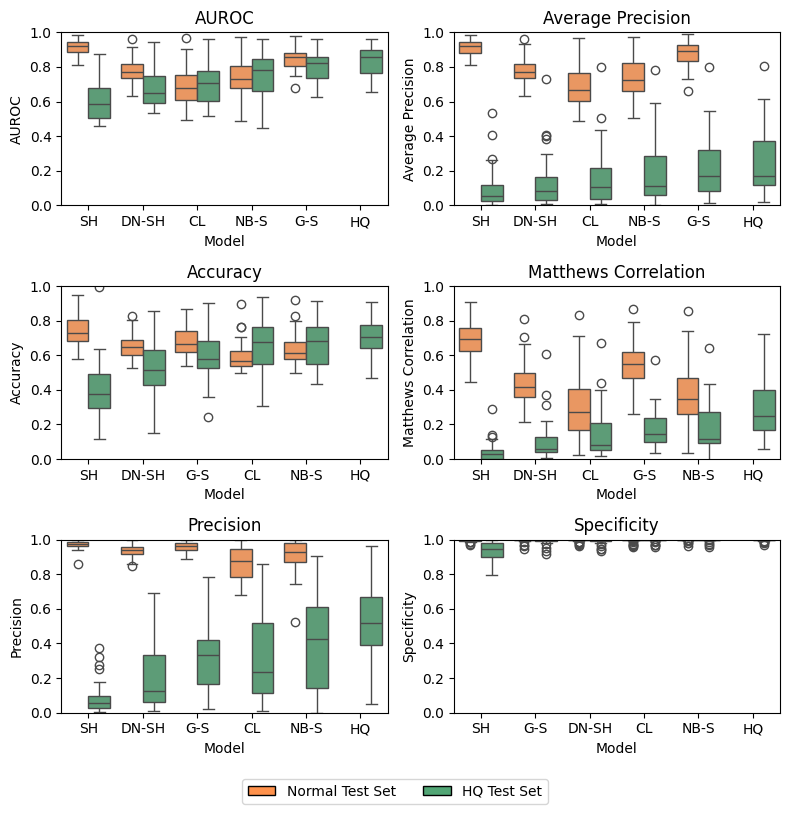

In [29]:
from matplotlib.patches import Patch

# Define the metrics to plot
metrics = [
    ('AUROC', 'AUROC_value', 'auroc_metric'),
    ('Average_Precision', 'Average_Precision_value', 'Average_Precision_metric'),
    ('Accuracy', 'Accuracy_value', 'Accuracy_metric'),
    ('Matthews_Correlation', 'Matthews_Correlation_value', 'Matthews_Correlation_metric'),
    ('Precision', 'Precision_value', 'Precision_metric'),
    ('Specificity', 'Specificity_value', 'Specificity_metric')
]

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(8,8))
axes = axes.flatten()

palette_standard = {'HQ': color_list[5], 'Standard': color_list[1]}
palette_hq = {'HQ': color_list[6]}

for idx, (metric_name, value_col, metric_col) in enumerate(metrics):
    ax = axes[idx]
    
    # Prepare melted data for this metric
    melted_data = pd.melt(
        grouped_avg.sort_values(by=['TF-neg_mode']),
        id_vars=['neg_mode', "celltype", 'TF'],
        value_vars=[metric_name, f'{metric_name}_HQ'],
        var_name=metric_col,
        value_name=value_col
    )

    
    # Map the metric names
    melted_data[metric_col] = melted_data[metric_col].map({
        metric_name: 'Standard', 
        f'{metric_name}_HQ': 'HQ'
    })
    
    melted_data['neg_mode_short'] = melted_data['neg_mode'].map(neg_mode_labels)
    
    # Order by HQ performance
    hq_rows = melted_data[melted_data[metric_col] == 'HQ']
    mean_per_mode = hq_rows.groupby("neg_mode_short")[value_col].mean().sort_values(ascending=True)
    neg_mode_order_metric = mean_per_mode.index.tolist()
    
    melted_data["neg_mode_short"] = pd.Categorical(
        melted_data["neg_mode_short"], 
        categories=neg_mode_order_metric, 
        ordered=True
    )
    
    # Filter out HQ training for standard boxplots
    plot_data = melted_data#[melted_data['neg_mode'] != 'HQ training']
    
    # Create boxplot
    sns.boxplot(
        data=plot_data,
        x='neg_mode_short',
        y=value_col,
        hue=metric_col,
        palette=palette_standard,
        dodge=True,
        ax=ax
    )
    
    # Set labels and title
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_name.replace('_', ' '))
    ax.set_title(f"{metric_name.replace('_', ' ')}")
    
    # Add reference line for AUROC
    # if metric_name == 'AUROC':
    #     ax.axhline(0.5, linestyle='--', color='red', linewidth=1)
    
    ax.set_ylim(0, 1)
    
    # Remove individual legends
    if ax.get_legend():
        ax.get_legend().remove()

# Add shared legend
legend_handles = [
    Patch(facecolor=palette_standard['Standard'], edgecolor='black', label='Normal Test Set'),
    Patch(facecolor=palette_standard['HQ'], edgecolor='black', label='HQ Test Set')
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/data/home/natant/Negatives/figures/review_all_metrics_comparison.svg", 
             format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
melted_group_avg = pd.melt(
    grouped_avg.sort_values(by=['TF-neg_mode']),
    id_vars=['neg_mode', "celltype", 'TF'],
    value_vars=['AUROC', 'AUROC_HQ'],
    var_name='auroc_metric',
    value_name='AUROC_value'
)

# Map the metric names to more descriptive labels
melted_group_avg['auroc_metric'] = melted_group_avg['auroc_metric'].map({'AUROC': 'Standard', 'AUROC_HQ': 'HQ'})

In [31]:
results_df["neg_mode_short"] = results_df["neg_mode"].map(neg_mode_labels)

In [32]:
# Calculate mean and median AUROC for each neg_mode-celltype combination
auroc_stats = results_df[results_df['neg_mode'] != 'HQ training'].groupby(['neg_mode_short', 'celltype'])['AUROC'].agg(['mean', 'median']).round(3)

# Reset index to make it easier to read
auroc_stats = auroc_stats.reset_index()
auroc_stats.columns = ['neg_mode', 'celltype', 'mean_AUROC', 'median_AUROC']

print("Mean and Median AUROC by neg_mode and celltype:")
print(auroc_stats)

# Pivot table for better visualization
pivot_mean = auroc_stats.pivot(index='celltype', columns='neg_mode', values='mean_AUROC')
pivot_median = auroc_stats.pivot(index='celltype', columns='neg_mode', values='median_AUROC')

print("\nMean AUROC by celltype and neg_mode:")
print(pivot_mean)

print("\nMedian AUROC by celltype and neg_mode:")
print(pivot_median)

Mean and Median AUROC by neg_mode and celltype:
  neg_mode celltype  mean_AUROC  median_AUROC
0       CL  GM12878       0.695         0.678
1    DN-SH  GM12878       0.784         0.773
2      G-S  GM12878       0.849         0.856
3     NB-S  GM12878       0.747         0.737
4       SH  GM12878       0.911         0.917

Mean AUROC by celltype and neg_mode:
neg_mode     CL  DN-SH    G-S   NB-S     SH
celltype                                   
GM12878   0.695  0.784  0.849  0.747  0.911

Median AUROC by celltype and neg_mode:
neg_mode     CL  DN-SH    G-S   NB-S     SH
celltype                                   
GM12878   0.678  0.773  0.856  0.737  0.917


In [33]:
# Calculate average AUROC per neg_mode across all TFs and celltypes
neg_mode_averages = results_df[results_df['neg_mode'] != 'HQ training'].groupby('neg_mode_short')['AUROC'].mean().sort_values(ascending=False)

print("Average AUROC by neg_mode (across all TFs and celltypes):")
for neg_mode, avg_auroc in neg_mode_averages.items():
    print(f"{neg_mode}: {avg_auroc:.3f}")

# Also calculate for AUROC_HQ
neg_mode_averages_hq = results_df[results_df['neg_mode'] != 'HQ training'].groupby('neg_mode_short')['AUROC_HQ'].mean().sort_values(ascending=False)

print("\nAverage AUROC_HQ by neg_mode (across all TFs and celltypes):")
for neg_mode, avg_auroc in neg_mode_averages_hq.items():
    print(f"{neg_mode}: {avg_auroc:.3f}")

Average AUROC by neg_mode (across all TFs and celltypes):
SH: 0.911
G-S: 0.849
DN-SH: 0.784
NB-S: 0.747
CL: 0.695

Average AUROC_HQ by neg_mode (across all TFs and celltypes):
G-S: 0.801
NB-S: 0.756
CL: 0.706
DN-SH: 0.680
SH: 0.612


In [34]:
# Calculate mean and median AUROC_HQ for each neg_mode-celltype combination
auroc_hq_stats = results_df[results_df['neg_mode'] != 'HQ training'].groupby(['neg_mode_short', 'celltype'])['AUROC_HQ'].agg(['mean', 'median']).round(3)

# Reset index to make it easier to read
auroc_hq_stats = auroc_hq_stats.reset_index()
auroc_hq_stats.columns = ['neg_mode', 'celltype', 'mean_AUROC_HQ', 'median_AUROC_HQ']

print("Mean and Median AUROC_HQ by neg_mode and celltype:")
print(auroc_hq_stats)

# Pivot table for better visualization
pivot_mean_hq = auroc_hq_stats.pivot(index='celltype', columns='neg_mode', values='mean_AUROC_HQ')
pivot_median_hq = auroc_hq_stats.pivot(index='celltype', columns='neg_mode', values='median_AUROC_HQ')

print("\nMean AUROC_HQ by celltype and neg_mode:")
print(pivot_mean_hq)

print("\nMedian AUROC_HQ by celltype and neg_mode:")
print(pivot_median_hq)

Mean and Median AUROC_HQ by neg_mode and celltype:
  neg_mode celltype  mean_AUROC_HQ  median_AUROC_HQ
0       CL  GM12878          0.706            0.699
1    DN-SH  GM12878          0.680            0.654
2      G-S  GM12878          0.801            0.821
3     NB-S  GM12878          0.756            0.779
4       SH  GM12878          0.612            0.573

Mean AUROC_HQ by celltype and neg_mode:
neg_mode     CL  DN-SH    G-S   NB-S     SH
celltype                                   
GM12878   0.706   0.68  0.801  0.756  0.612

Median AUROC_HQ by celltype and neg_mode:
neg_mode     CL  DN-SH    G-S   NB-S     SH
celltype                                   
GM12878   0.699  0.654  0.821  0.779  0.573


In [35]:
# Calculate average AUROC_HQ per neg_mode across all TFs and celltypes (including HQ training)
neg_mode_averages_hq_all = results_df.groupby('neg_mode_short')['AUROC_HQ'].mean().sort_values(ascending=False)

print("Average AUROC_HQ by neg_mode (across all individual TF runs, including HQ training):")
for neg_mode, avg_auroc in neg_mode_averages_hq_all.items():
    print(f"{neg_mode}: {avg_auroc:.3f}")

Average AUROC_HQ by neg_mode (across all individual TF runs, including HQ training):
G-S: 0.801
NB-S: 0.756
CL: 0.706
DN-SH: 0.680
SH: 0.612
HQ: nan


In [36]:
melted_group_avg

,neg_mode,celltype,TF,auroc_metric,AUROC_value
0,HQ training,GM12878,ATF2_(SC-81188),Standard,NaN
1,celltype,GM12878,ATF2_(SC-81188),Standard,0.640860
2,dinucl_sampled,GM12878,ATF2_(SC-81188),Standard,0.791551
3,dinucl_shuffled,GM12878,ATF2_(SC-81188),Standard,0.783179
4,neighbors,GM12878,ATF2_(SC-81188),Standard,0.699562
...,...,...,...,...,...
427,celltype,GM12878,Znf143_(16618-1-AP),HQ,0.867375
428,dinucl_sampled,GM12878,Znf143_(16618-1-AP),HQ,0.901585
429,dinucl_shuffled,GM12878,Znf143_(16618-1-AP),HQ,0.881810
430,neighbors,GM12878,Znf143_(16618-1-AP),HQ,0.907919


## Figure: Motif performance

In [37]:
nice_names = {
    "dinucl_sampled": "Genome Sampled",
    "dinucl_shuffled": "Dinucl Shuffled",
    "neighbors": "Neighborhood Sampled",
    "shuffled": "Shuffled",
    "motif": "PWM",
    "celltype": "Cell Line Sampled",
    "HQ training": "HQ"
}

In [38]:
fused_df

,TF,AUROC_HQ,neg_mode,celltype
0,ATF2_(SC-81188),0.722720,HQ training,GM12878
1,ATF2_(SC-81188),0.621152,celltype,GM12878
2,ATF2_(SC-81188),0.680566,dinucl_sampled,GM12878
3,ATF2_(SC-81188),0.613966,dinucl_shuffled,GM12878
4,ATF2_(SC-81188),0.646343,neighbors,GM12878
...,...,...,...,...
277,TCF12,0.453934,motif,HepG2
278,TCF7L2,0.836529,motif,HepG2
279,BHLHE40,0.884376,motif,HepG2
280,IRF3,0.519302,motif,HepG2


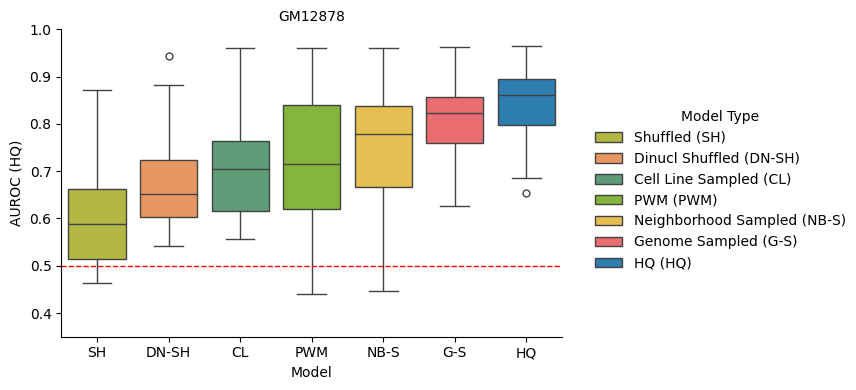

In [49]:
# Compute mean AUROC_HQ per neg_mode_short for ordering
fused_df = fused_df[fused_df["celltype"] == "GM12878"]
fused_df["neg_mode_short"] = fused_df["neg_mode"].map(neg_mode_labels)
mean_per_mode = fused_df.groupby("neg_mode_short")["AUROC_HQ"].mean().sort_values()
neg_mode_order = mean_per_mode.index.tolist()

# Set categorical order for plotting
fused_df["neg_mode_short"] = pd.Categorical(fused_df["neg_mode_short"], categories=neg_mode_order, ordered=True)

# Create nice names with abbreviations in brackets
nice_names_with_abbrev = {
    "dinucl_sampled": "Genome Sampled (G-S)",
    "dinucl_shuffled": "Dinucl Shuffled (DN-SH)",
    "neighbors": "Neighborhood Sampled (NB-S)",
    "shuffled": "Shuffled (SH)",
    "motif": "PWM (PWM)",
    "celltype": "Cell Line Sampled (CL)",
    "HQ training": "HQ (HQ)"
}

# Add a column with nice names for neg_mode, also with the same categorical order
fused_df["neg_mode_nice"] = fused_df["neg_mode"].map(nice_names_with_abbrev)

# Create inverse mapping for neg_mode_labels
neg_mode_labels_inv = {v: k for k, v in neg_mode_labels.items()}

nice_name_order = [nice_names_with_abbrev[neg_mode_labels_inv[short]] for short in neg_mode_order]
fused_df["neg_mode_nice"] = pd.Categorical(fused_df["neg_mode_nice"], categories=nice_name_order, ordered=True)

g = sns.catplot(
    data=fused_df,
    x='neg_mode_short',
    col='celltype',
    y='AUROC_HQ',
    hue='neg_mode_nice',
    kind='box',
    height=4,
    aspect=0.8,
    palette={nice_names_with_abbrev[k]: color_list[i] for i, k in enumerate(neg_mode_labels.keys())}
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Model", "AUROC (HQ)")
g._legend.set_bbox_to_anchor((1, 0.5))
g._legend.set_loc("center left")
g._legend.set_title("Model Type")
g.set(ylim=(0.35, 1))
for ax in g.axes.flatten():
    ax.axhline(0.5, linestyle='--', color='red', linewidth=1)
plt.tight_layout()
#plt.savefig("/data/home/natant/Negatives/figures/Baselines.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_2725293/2264509360.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fused_df["neg_mode_short"] = fused_df["neg_mode"].map(neg_mode_labels)
/tmp/ipykernel_2725293/2264509360.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fused_df["neg_mode_short"] = pd.Categorical(fused_df["neg_mode_short"], categories=neg_mode_order, ordered=True)
/tmp/ipykernel_2725293/2264509360.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

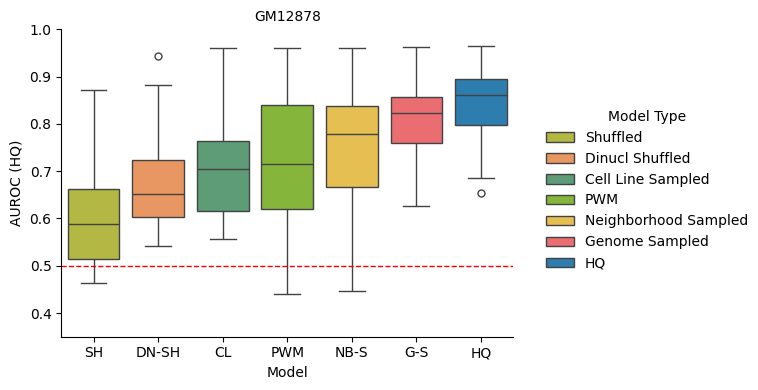

In [40]:
# Compute mean AUROC_HQ per neg_mode_short for ordering
fused_df["neg_mode_short"] = fused_df["neg_mode"].map(neg_mode_labels)
mean_per_mode = fused_df.groupby("neg_mode_short")["AUROC_HQ"].mean().sort_values()
neg_mode_order = mean_per_mode.index.tolist()

# Set categorical order for plotting
fused_df["neg_mode_short"] = pd.Categorical(fused_df["neg_mode_short"], categories=neg_mode_order, ordered=True)

# Add a column with nice names for neg_mode, also with the same categorical order
fused_df["neg_mode_nice"] = fused_df["neg_mode"].map(nice_names)

# Create inverse mapping for neg_mode_labels
neg_mode_labels_inv = {v: k for k, v in neg_mode_labels.items()}

nice_name_order = [nice_names[neg_mode_labels_inv[short]] for short in neg_mode_order]
fused_df["neg_mode_nice"] = pd.Categorical(fused_df["neg_mode_nice"], categories=nice_name_order, ordered=True)



g = sns.catplot(
    data=fused_df,
    x='neg_mode_short',
    col='celltype',
    y='AUROC_HQ',
    hue='neg_mode_nice',
    kind='box',
    height=4,
    aspect=0.8,
    palette={nice_names[k]: color_list[i] for i, k in enumerate(neg_mode_labels.keys())}
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Model", "AUROC (HQ)")
g._legend.set_bbox_to_anchor((1, 0.5))
g._legend.set_loc("center left")
g._legend.set_title("Model Type")
g.set(ylim=(0.35, 1))
for ax in g.axes.flatten():
    ax.axhline(0.5, linestyle='--', color='red', linewidth=1)
plt.tight_layout()
#plt.savefig("/data/home/natant/Negatives/figures/Baselines.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [41]:
alternative_colors = {'celltype': '#1f77b4',
 'dinucl_sampled': '#ff7f0e',
 'dinucl_shuffled': '#2ca02c',
 'HQ': '#d62728',
 'neighbors': '#9467bd',
 'shuffled': '#8c564b'}

In [42]:
neg_mode_labels

{'dinucl_sampled': 'G-S',
 'dinucl_shuffled': 'DN-SH',
 'neighbors': 'NB-S',
 'shuffled': 'SH',
 'motif': 'PWM',
 'celltype': 'CL',
 'HQ training': 'HQ'}

In [43]:
{nice_names_with_abbrev[k]: color_list[i] for i, k in enumerate(neg_mode_labels.keys())}

{'Genome Sampled (G-S)': '#ff595e',
 'Dinucl Shuffled (DN-SH)': '#ff924c',
 'Neighborhood Sampled (NB-S)': '#ffca3a',
 'Shuffled (SH)': '#c5ca30',
 'PWM (PWM)': '#8ac926',
 'Cell Line Sampled (CL)': '#52a675',
 'HQ (HQ)': '#1982c4'}

## Figure: Motif vs Dincul shuffled

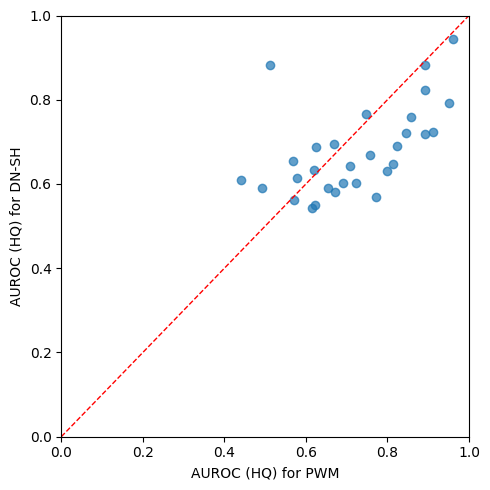

In [44]:
import matplotlib.pyplot as plt

# Filter fused_df for only 'motif' and 'dinucl_shuffled' neg_mode
compare_modes = ['motif', 'dinucl_shuffled']
df1 = fused_df[fused_df['neg_mode'] == 'motif'][['TF', 'celltype', 'AUROC_HQ']]
df2 = fused_df[fused_df['neg_mode'] == 'dinucl_shuffled'][['TF', 'celltype', 'AUROC_HQ']]

# Merge on TF and celltype to align the two modes
merged = pd.merge(
    df1, df2,
    on=['TF', 'celltype'],
    suffixes=('_motif', '_dinucl_shuffled')
)

plt.figure(figsize=(5, 5))
plt.scatter(
    merged['AUROC_HQ_motif'],
    merged['AUROC_HQ_dinucl_shuffled'],
    alpha=0.7
)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='y=x')
plt.xlabel('AUROC (HQ) for PWM')
plt.ylabel('AUROC (HQ) for DN-SH')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("/data/home/natant/Negatives/figures/performance_comparison_DN-SH_vs_PWM.svg", 
#             format='svg', dpi=300, bbox_inches='tight')
plt.show()

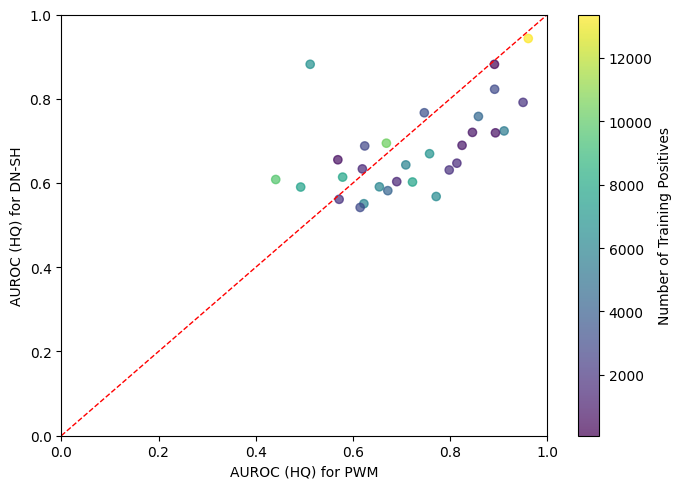

In [45]:
import matplotlib.pyplot as plt

# Filter fused_df for only 'motif' and 'dinucl_shuffled' neg_mode
compare_modes = ['motif', 'dinucl_shuffled']
df1 = fused_df[fused_df['neg_mode'] == 'motif'][['TF', 'celltype', 'AUROC_HQ']]
df2 = fused_df[fused_df['neg_mode'] == 'dinucl_shuffled'][['TF', 'celltype', 'AUROC_HQ']]

# Merge on TF and celltype to align the two modes
merged = pd.merge(
    df1, df2,
    on=['TF', 'celltype'],
    suffixes=('_motif', '_dinucl_shuffled')
)

# Get number of positives for each TF-celltype combination
# Use grouped_avg to get num_training_positives
num_positives = grouped_avg[grouped_avg['neg_mode'] == 'dinucl_shuffled'][['TF', 'celltype', 'num_training_positives']].drop_duplicates()
merged = pd.merge(merged, num_positives, on=['TF', 'celltype'], how='left')
merged[(merged["num_training_positives"] <= 16000) & (merged["num_training_positives"] >= 500)]

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    merged['AUROC_HQ_motif'],
    merged['AUROC_HQ_dinucl_shuffled'],
    c=merged['num_training_positives'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(scatter, label='Number of Training Positives')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='y=x')
plt.xlabel('AUROC (HQ) for PWM')
plt.ylabel('AUROC (HQ) for DN-SH')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("/data/home/natant/Negatives/figures/performance_comparison_DN-SH_vs_PWM.svg", 
#             format='svg', dpi=300, bbox_inches='tight')
plt.show()

## Figure: Dataset size

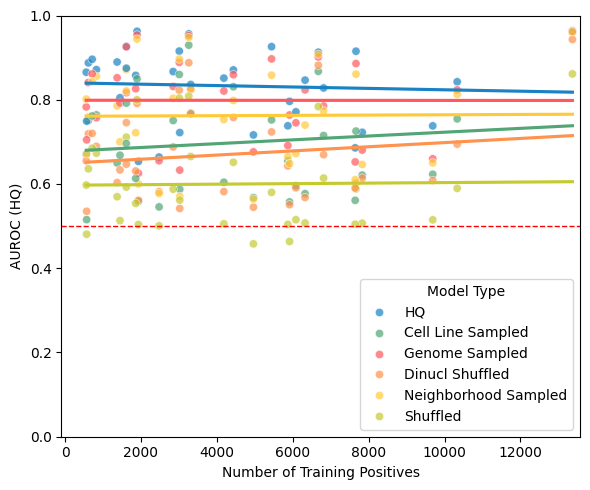

In [46]:
plt.figure(figsize=(6, 5))
# Filter out datapoints with more than 16000 positives and less than 1000 positives
plot_data = grouped_avg[(grouped_avg["num_training_positives"] <= 16000) & (grouped_avg["num_training_positives"] >= 500)]

# Prepare color palette for nice_names
palette = {nice_names[k]: color_list[i] for i, k in enumerate(neg_mode_labels.keys())}

sns.scatterplot(
    data=plot_data,
    x="num_training_positives",
    y="AUROC_HQ",
    hue=plot_data["neg_mode"].map(nice_names),
    palette=palette,
    alpha=0.7
)

# Add trend lines for each neg_mode using nice names and colors
for neg_mode in plot_data["neg_mode"].unique():
    label = nice_names[neg_mode]
    color = palette[label]
    subset = plot_data[plot_data["neg_mode"] == neg_mode]
    sns.regplot(
        data=subset,
        x="num_training_positives",
        y="AUROC_HQ",
        scatter=False,
        color=color,
        ci=None,
    )

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
plt.ylim(0, 1)
plt.xlim(-100, plot_data["num_training_positives"].max() + 200)
plt.xlabel("Number of Training Positives")
plt.ylabel("AUROC (HQ)")
plt.legend(title="Model Type", loc='lower right', bbox_to_anchor=(1, 0))
plt.tight_layout()
plt.savefig("/data/home/natant/Negatives/figures/dataset_size.svg", 
            format='svg', dpi=300, bbox_inches='tight')
plt.show()
